# Quantitative Portfolio Optimization & Risk Analysis

## 1. Project Goal

In this project, we apply quantitative finance techniques in order to construct and analyze a stock portfolio.

The goal is to investigate the relationship between risk and return using logarithmic returns, volatility, correlation matrices, covariance matrices, Monte Carlo simulation, and portfolio optimization techniques.

More specifically, having fixed the assets composing our portfolio, we aim to identify the optimal weights in order to achieve an efficient trade-off between expected return and risk, based on the principles of Modern Portfolio Theory.

## 2. Ipmorting Libraries

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

from scipy.optimize import minimize

## 3. Data Collection

We collect historical stock data for companies from different market sectors:  technology, healthcare, financials, consumer staples, and energy. 

In this way, one can better examine the effects of diversification and correlation on portfolio risk and performance.

In addition to our portfolio stocks, we include the S&P 500 index as a benchmark representing the overall market. We shall compare the portfolio's performance with that of the index.

In [53]:
stocks = ['AAPL', 'MSFT', 'JNJ', 'JPM', 'KO', 'XOM']

benckmark = '^GSPC'

In [54]:
data = yf.download(stocks, start='2020-01-01', end='2025-01-01', auto_adjust=False)['Adj Close']

data.head()

[*********************100%***********************]  6 of 6 completed


Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Date,,,,,,
2020-01-02,72.333870,122.638214,118.430313,45.432709,152.158386,52.947029
2020-01-03,71.630630,121.218338,116.867455,45.184849,150.263763,52.521370
2020-01-06,72.201416,121.067146,116.774544,45.168331,150.652176,52.924618
2020-01-07,71.861839,121.806473,114.789307,44.821316,149.278549,52.491505
2020-01-08,73.017838,121.789688,115.684784,44.903938,151.656326,51.699902


In [55]:
benchmark_data = yf.download(benckmark, start='2020-01-01', end='2025-01-01', auto_adjust=False)['Adj Close']

benchmark_data.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2020-01-02,3257.850098
2020-01-03,3234.850098
2020-01-06,3246.280029
2020-01-07,3237.179932
2020-01-08,3253.050049


**Remark:** Throughout this project we use adjusted closing prices, due to their providing a more accurate representation of asset values.

**Remark:** The selected time period (2020-2025) is particularly interesting, because it includes several events which significantly influenced market performance, such as COVID-19 and its consequences.

Moreover, the five-year time horizon provides a sufficient number of observations for our statistical analysis. 

# 4. Data Inspection & Cleaning

Before proceeding with the analysis, we inspect the structure and quality of our datasets.

In [56]:
data.shape

(1258, 6)

In [62]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1258 non-null   float64
 1   JNJ     1258 non-null   float64
 2   JPM     1258 non-null   float64
 3   KO      1258 non-null   float64
 4   MSFT    1258 non-null   float64
 5   XOM     1258 non-null   float64
dtypes: float64(6)
memory usage: 68.8 KB


In [58]:
data.isnull().sum()

Ticker
AAPL    0
JNJ     0
JPM     0
KO      0
MSFT    0
XOM     0
dtype: int64

In [59]:
data.describe()

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
count,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000,1258.000000
mean,151.377786,143.684102,135.491523,51.910027,286.342938,73.433010
std,41.851999,11.824775,37.831734,7.368286,81.234207,28.858525
min,54.163704,93.970840,66.763306,31.304211,128.636353,23.823559
25%,126.279110,138.840370,109.972450,46.773101,227.026981,46.591518
50%,149.968590,145.948967,132.128448,53.756042,274.198456,79.235245
75%,175.902004,151.726967,147.840576,56.735521,330.945076,99.136551
max,257.375610,165.628799,242.758453,69.427238,461.322601,118.348557


The descriptive statistics provide an initial overview of the price levels and variability of the selected assets over the examined period.

We now perform the same inspection process for the benchmark dataset.

In [60]:
benchmark_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ^GSPC   1258 non-null   float64
dtypes: float64(1)
memory usage: 19.7 KB


In [61]:
benchmark_data.isnull().sum()

Ticker
^GSPC    0
dtype: int64

**Remark:** Both datasets contain no missing values.

# 5. Exploratory Price Analysis

In this section, we examine the evolution of both the portfolio asset prices and the benchmark index over time.

We begin with the portfolio assets.

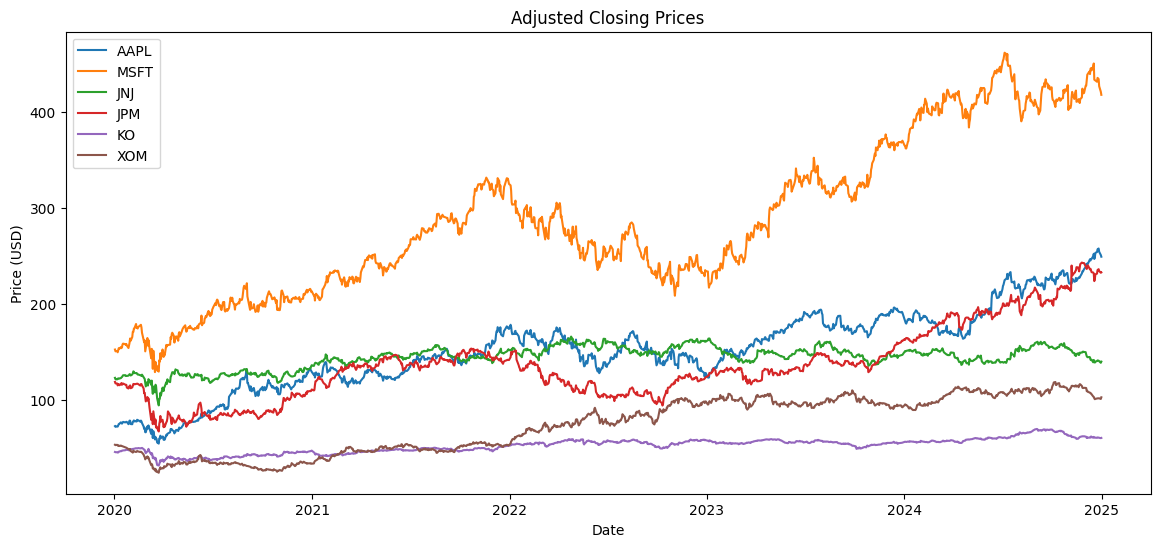

In [77]:
plt.figure(figsize=(14,6))

for stock in stocks:
    
    plt.plot(data[stock], label=stock)

plt.title('Adjusted Closing Prices')

plt.xlabel('Date')

plt.ylabel('Price (USD)')

plt.legend()

plt.show()

**Remark:** All assets exhibit an overall upward trend. However, noticeable differences in growth rate and volatility can still be observed.

Next, we examine the S&P 500 graph, which represents the overall market behavior.

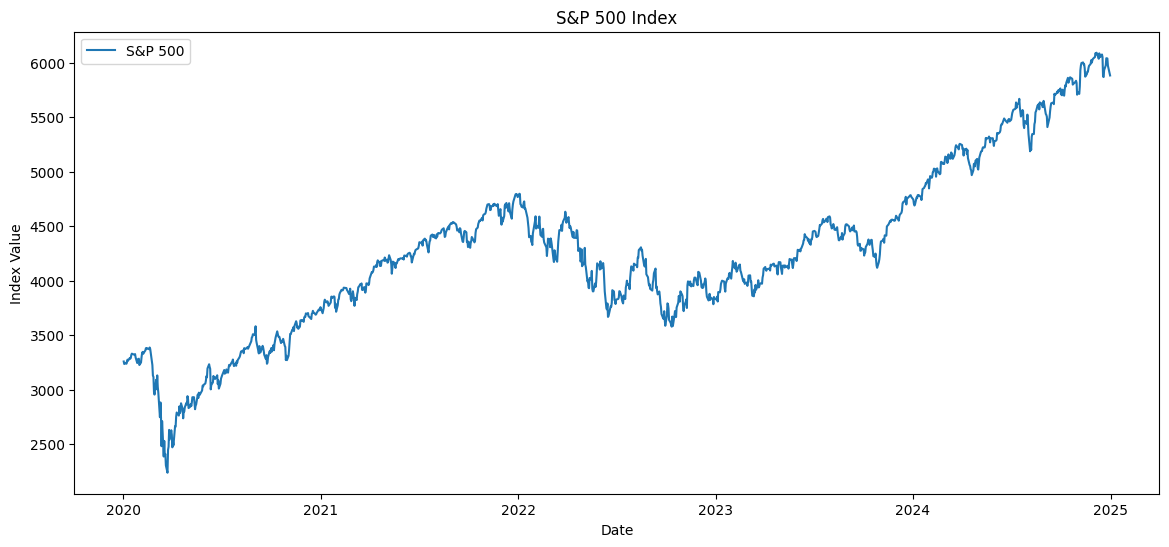

In [67]:
plt.figure(figsize=(14,6))

plt.plot(benchmark_data, label='S&P 500')

plt.title('S&P 500 Index')

plt.xlabel('Date')

plt.ylabel('Index Value')

plt.legend()

plt.show()

**Remark:** This graph also demonstrates an overall upward trend accompanied by significant fluctuations. More precisely, a notable decline can be observed during early 2020, mainly due to COVID-19 and the resulting economic uncertainty. Nevertheless, this period was followed by a strong market recovery in the following years.

Since the assets are on different price scales, we normalize all price series dividing each one by its very first value. This makes the data more suitable for comparison.

In [68]:
normalized_data = data / data.iloc[0]

normalized_benchmark = benchmark_data / benchmark_data.iloc[0]

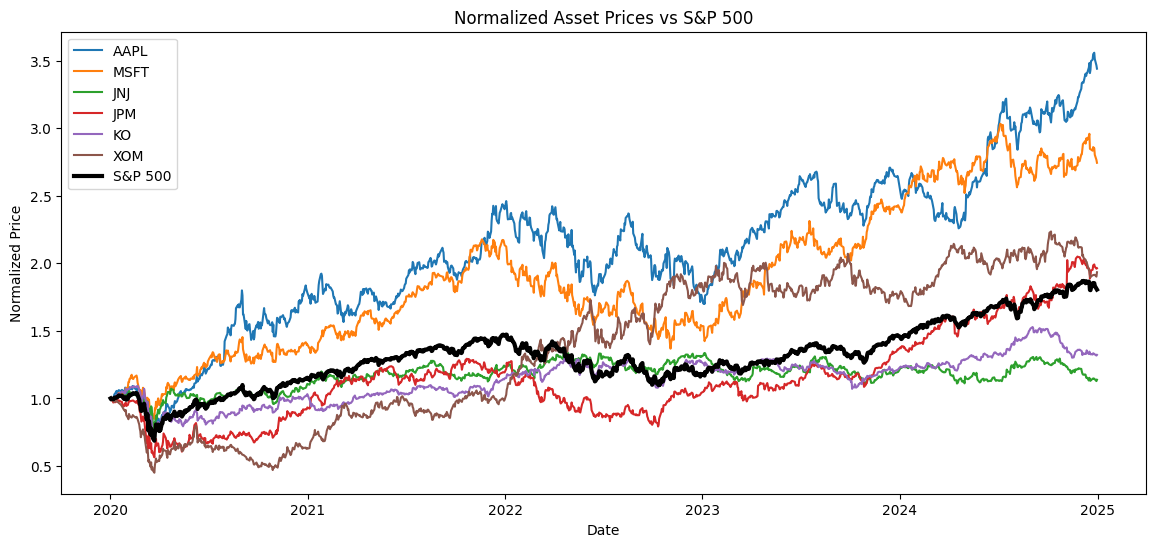

In [76]:
plt.figure(figsize=(14,6))

for stock in stocks:
    
    plt.plot(normalized_data[stock], label=stock)

plt.plot(normalized_benchmark, label='S&P 500', linewidth=3, color='black')

plt.title('Normalized Asset Prices vs S&P 500')

plt.xlabel('Date')

plt.ylabel('Normalized Price')

plt.legend()

plt.show()

**Remark:** Comparing the line plots, one can identify the assets which outperformed or underperformed relative to the S&P 500.

## 6. Log Returns Analysis

We now compute the logarithmic returns of the portfolio assets and the benchmark.

In [81]:
log_returns = np.log(data / data.shift(1))

log_returns.head()

Ticker,AAPL,JNJ,JPM,KO,MSFT,XOM
Date,,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN
2020-01-03,-0.009770,-0.011645,-0.013284,-0.005470,-0.012530,-0.008072
2020-01-06,0.007937,-0.001248,-0.000795,-0.000366,0.002582,0.007648
2020-01-07,-0.004714,0.006088,-0.017147,-0.007712,-0.009160,-0.008217
2020-01-08,0.015958,-0.000138,0.007771,0.001842,0.015803,-0.015195


In [82]:
benchmark_log_returns = np.log(benchmark_data / benchmark_data.shift(1))

benchmark_log_returns.head()

Ticker,^GSPC
Date,
2020-01-02,NaN
2020-01-03,-0.007085
2020-01-06,0.003527
2020-01-07,-0.002807
2020-01-08,0.004890


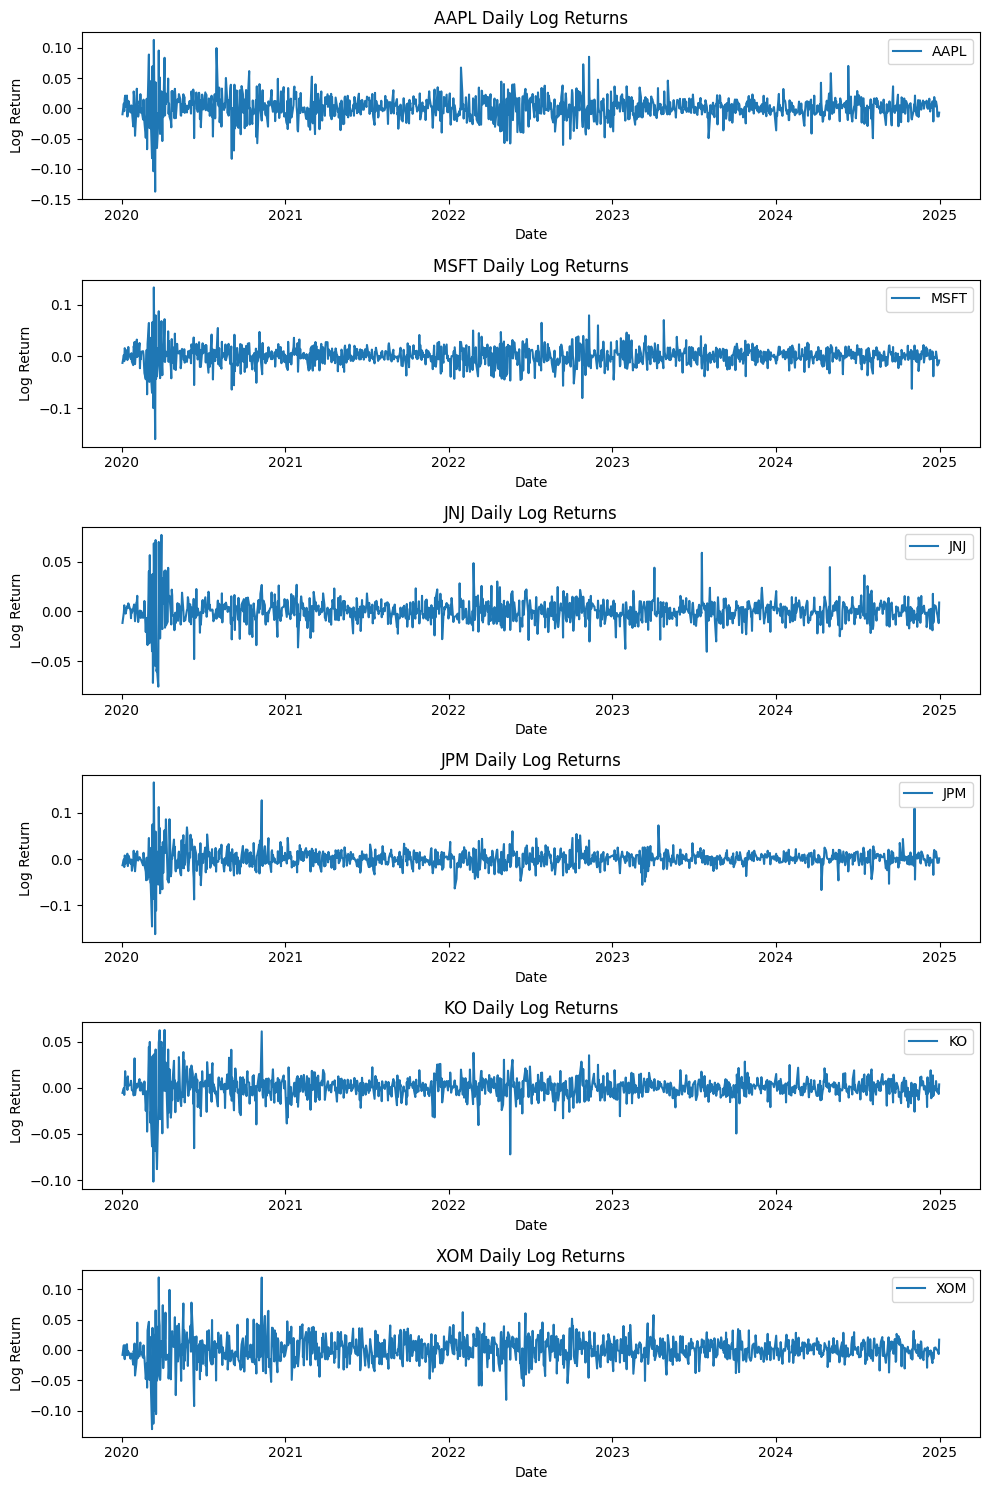

In [103]:
plt.figure(figsize=(10,15))

for stock in stocks:
    
    plt.subplot(len(stocks), 1, stocks.index(stock)+1)
    
    plt.plot(log_returns[stock], label=stock)
    
    plt.title(str(stock) + ' Daily Log Returns')
    
    plt.xlabel('Date')
    
    plt.ylabel('Log Return')
    
    plt.legend()

plt.tight_layout()

plt.show()

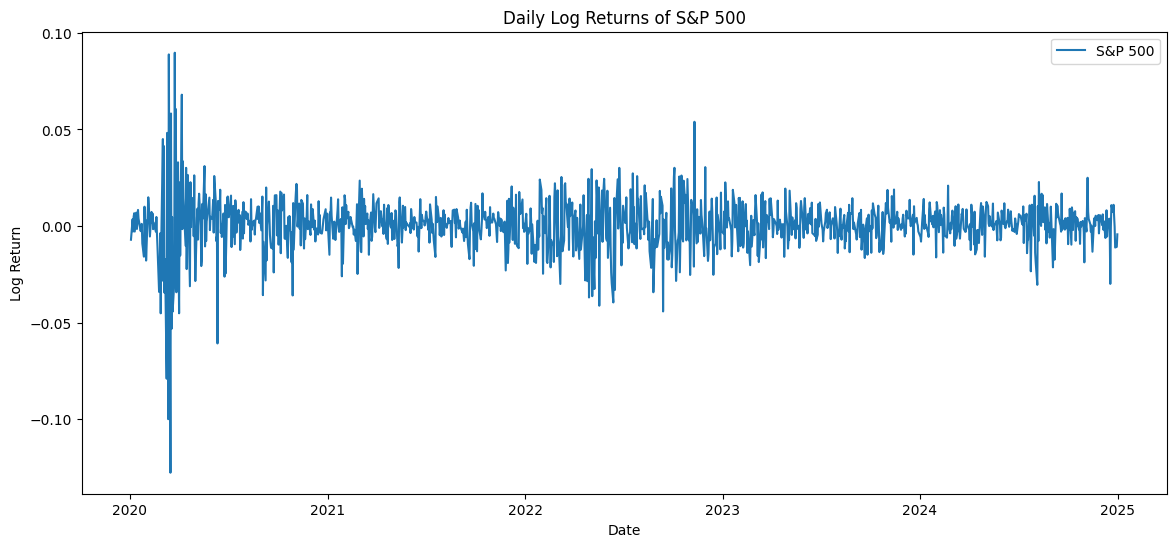

In [104]:
plt.figure(figsize=(14,6))

plt.plot(benchmark_log_returns, label='S&P 500')

plt.title('Daily Log Returns of S&P 500')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.legend()
plt.show()

**Remark:** Both the portfolio asset returns and S&P 500 log returns fluctuate around zero and exhibit periods of increased volatility, especially during market stress periods.

## 7. Correlation & Covariance Analysis